<a href="https://colab.research.google.com/github/Toby-U/eml-stuff/blob/main/img_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos.tar', origin = dataset_url, extract = True) #This downloads and unzips the compressed file

data_dir = pathlib.Path(data_dir).with_suffix('')

data_dir = data_dir / 'flower_photos'
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
print(data_dir)





228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
3670
/root/.keras/datasets/flower_photos_extracted/flower_photos


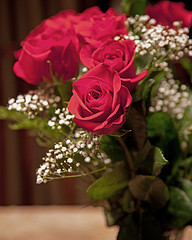

In [ ]:
roses= list(data_dir.glob('roses/*'))
PIL.Image.open(str(roses[0]))
PIL.Image.open(roses[1])

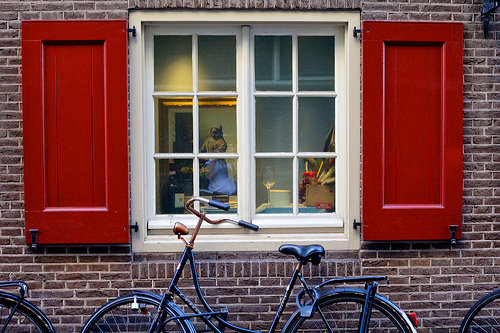

In [ ]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[6]))

In [ ]:

batch_size = 32
img_height = 180
img_width = 180


train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed =123,
    image_size = (img_height,img_width),
    batch_size = batch_size)


val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset = "validation",
    seed = 123,
    image_size = (img_height,img_width),
    batch_size = batch_size

    )

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
# Take one batch from the training dataset
for images, labels in train_ds.take(2):
    print(f"Shape of images in one batch: {images.shape}")
    print(f"Shape of labels in one batch: {labels.shape}")

print(f"\nAs you can see, for the images, the shape is (batch_size, img_height, img_width, channels), and for the labels, it's (batch_size,). This demonstrates how `tf.keras.utils.image_dataset_from_directory` groups your data into batches of {batch_size}.")

Shape of images in one batch: (32, 180, 180, 3)
Shape of labels in one batch: (32,)
Shape of images in one batch: (32, 180, 180, 3)
Shape of labels in one batch: (32,)

As you can see, for the images, the shape is (batch_size, img_height, img_width, channels), and for the labels, it's (batch_size,). This demonstrates how `tf.keras.utils.image_dataset_from_directory` groups your data into batches of 32.


In [ ]:
class_names = val_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


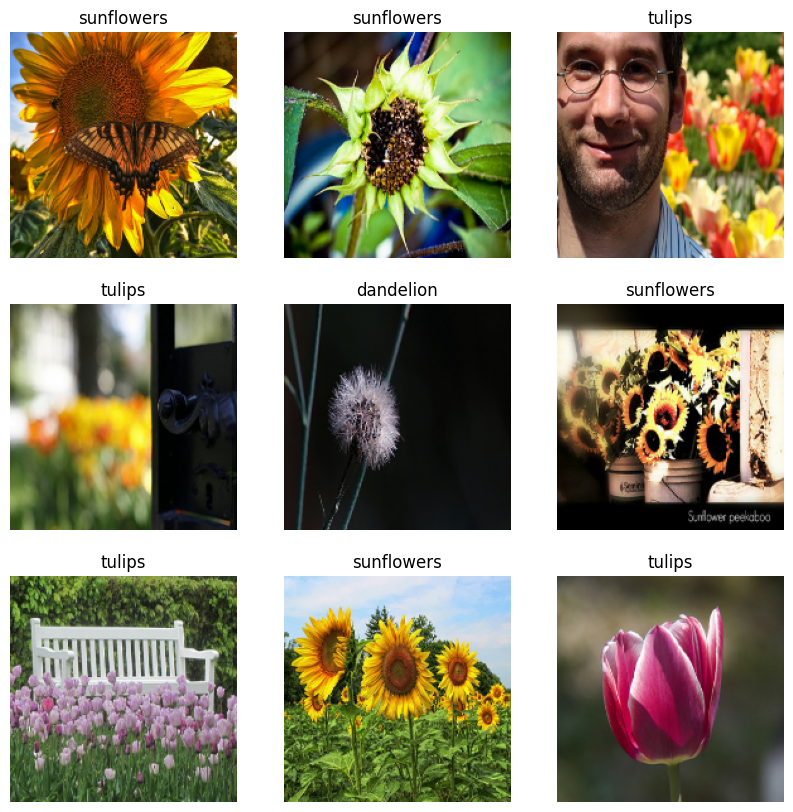

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [ ]:
# Standardise Data
normalization_layer = layers.Rescaling(1./255)
normalization_layer

<Rescaling name=rescaling, built=False>

In [ ]:
num_classes = len(class_names)

model = Sequential([
    layers.Rescaling(1./255, input_shape = (img_height, img_width,3)),
    layers.Conv2D(16,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(num_classes)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs
)



Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 655ms/step - accuracy: 0.4162 - loss: 1.3724 - val_accuracy: 0.5300 - val_loss: 1.1286
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 60s 654ms/step - accuracy: 0.5960 - loss: 1.0318 - val_accuracy: 0.6185 - val_loss: 1.0094
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 642ms/step - accuracy: 0.6655 - loss: 0.8719 - val_accuracy: 0.6431 - val_loss: 0.8951
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 59s 645ms/step - accuracy: 0.7551 - loss: 0.6622 - val_accuracy: 0.6335 - val_loss: 0.9836
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 61s 663ms/step - accuracy: 0.8341 - loss: 0.4521 - val_accuracy: 0.6512 - val_loss: 0.9957
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 86s 706ms/step - accuracy: 0.9179 - loss: 0.2616 - val_accuracy: 0.6362 - val_loss: 1.1031
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 679ms/step - accuracy: 0.9564 - loss: 0.1426 - val_accuracy: 0.6485 - val_loss: 1.3086
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 677ms/step - accuracy: 0.9728 - loss: 0.0847 - val_accu

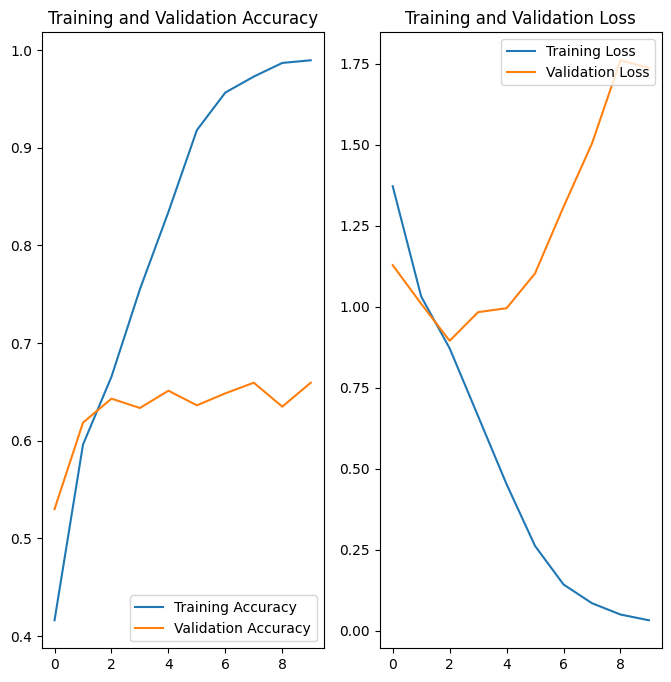

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:

data_augmentation = keras.Sequential(
      [
          layers.RandomFlip("horizontal_and_vertical",input_shape = (img_height,img_width,3)),
          layers.RandomRotation(0.1 ),
          layers.RandomZoom(0.1)
      ]
  )



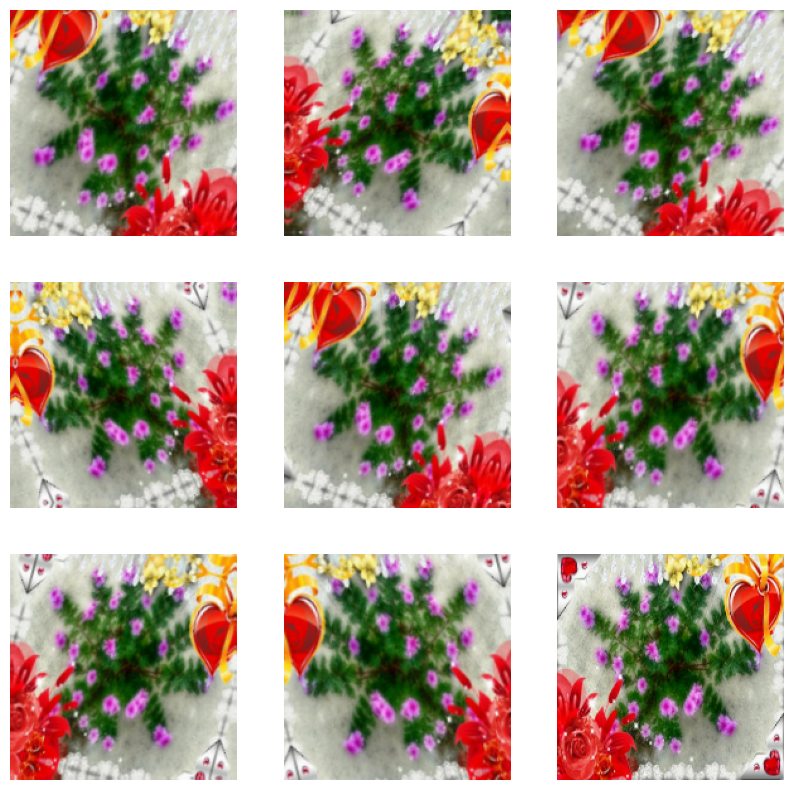

In [ ]:
plt.figure(figsize = (10,10))

for images, _ in train_ds.take(1):
  image = images[0]
  for i in range(9):
    augmented_images = data_augmentation(tf.expand_dims(image,0))[0]
    # The data augmentation pipeline only accespts images in batche
    # Hence we expand the dimensions of the single image we collected by including a batch dimension
    #Then we get the only element in that batch with "[0]" and plot it

    ax = plt.subplot(3,3,i+1)
    plt.imshow(augmented_images.numpy().astype("uint8"))
    plt.axis("off")



In [ ]:
new_model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape = (img_height, img_width,3)),
    layers.Conv2D(16,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding = 'same', activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128, activation = 'relu'),
    layers.Dense(num_classes)

])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
new_model.compile(optimizer='adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics = ['accuracy'])
new_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 15
history = new_model.fit(train_ds, validation_data = val_ds, epochs = epochs)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 750ms/step - accuracy: 0.8035 - loss: 0.4987 - val_accuracy: 0.6989 - val_loss: 0.7906
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 737ms/step - accuracy: 0.8297 - loss: 0.4432 - val_accuracy: 0.7398 - val_loss: 0.6770
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 746ms/step - accuracy: 0.8375 - loss: 0.4371 - val_accuracy: 0.7480 - val_loss: 0.6665
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 738ms/step - accuracy: 0.8375 - loss: 0.4336 - val_accuracy: 0.7262 - val_loss: 0.6932
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 67s 732ms/step - accuracy: 0.8423 - loss: 0.4224 - val_accuracy: 0.7371 - val_loss: 0.7002
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 742ms/step - accuracy: 0.8610 - loss: 0.3841 - val_accuracy: 0.7480 - val_loss: 0.7243
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 740ms/step - accuracy: 0.8593 - loss: 0.3762 - val_accuracy: 0.7098 - val_loss: 0.7800
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 746ms/step - accuracy: 0.8651 - loss: 0.3510 - val_accu

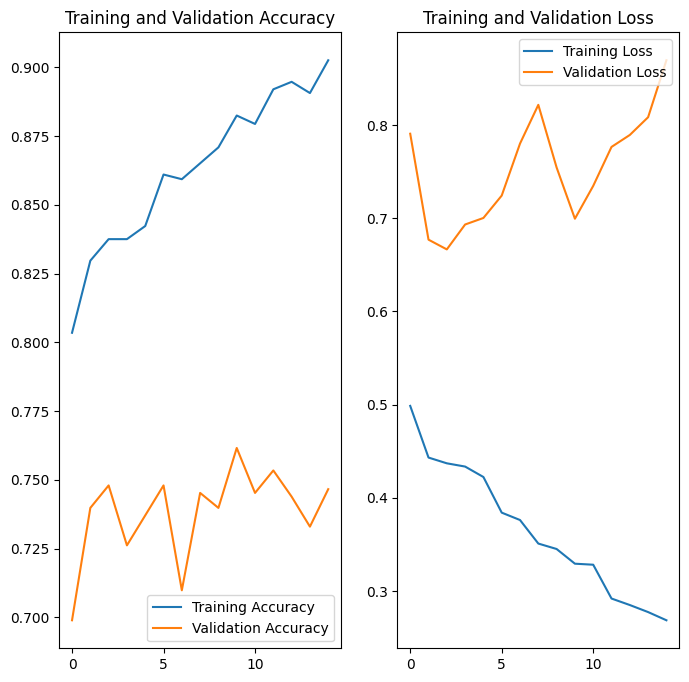

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()#

In [ ]:
sunflower_url = sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin= sunflower_url)

img = tf.keras.utils.load_img(sunflower_path, target_size= (img_width,img_height))
img_arr= tf.keras.utils.img_to_array(img)
img_arr = tf.expand_dims(img_arr,0) # batch stuff

predictions = model.predict(img_arr)

score = tf.nn.softmax(predictions[0])

print("predictions --", predictions)
print("score --", score)

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
predictions -- [[-19.67926    -7.6372595   7.5970035  26.925995   20.781816 ]]
score -- tf.Tensor([5.7367237e-21 9.7372875e-16 4.0234158e-09 9.9785870e-01 2.1413432e-03], shape=(5,), dtype=float32)
This image most likely belongs to sunflowers with a 99.79 percent confidence.


In [ ]:
# TF Lite

converter  = tf.lite.TFLiteConverter.from_keras_model(new_model)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
TF_MODEL_FILE_PATH = 'model.tflite'

interpreter = tf.lite.Interpreter(model_path = TF_MODEL_FILE_PATH)
interpreter.get_signature_list()

Saved artifact at '/tmp/tmpbnlmpmag'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136901728794384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728796496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728795152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728794576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728794768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728793232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728794192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728793616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728791888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136901728790736: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{'serving_default': {'inputs': ['keras_tensor_28'], 'outputs': ['output_0']}}

In [ ]:
classify_lite = interpreter.get_signature_runner('serving_default')
classify_lite

In [ ]:
predictions_lite = classify_lite(keras_tensor_28=img_arr)['output_0']
score_lite = tf.nn.softmax(predictions_lite)


In [ ]:
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score_lite)], 100 * np.max(score_lite))
)

This image most likely belongs to sunflowers with a 99.73 percent confidence.


In [ ]:
print(np.max(np.abs(predictions - predictions_lite)))

23.035475
